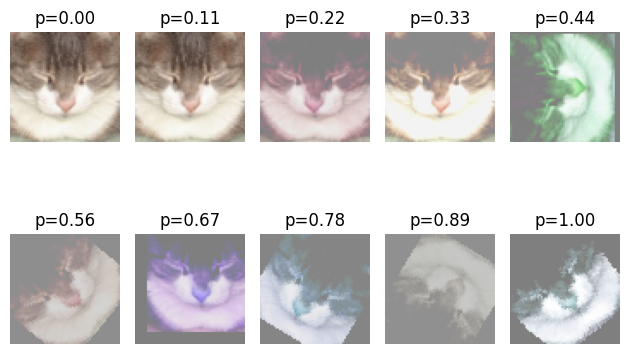

In [15]:
import sys

sys.path.append('..')

from adaptive_augmentation import get_ada_aug
from dataset import get_loader
from configs import Config
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision.transforms import functional

# Load dataset from "data/cats" and augment with changing p using adaptive_augmentation.get_ada_aug
rows = 2
cols = 5
p = np.linspace(0, 1, rows * cols)
config = Config.from_defaults()
config.data.root = "../data-filtered"
train_loader, _,_ = get_loader(config)
dataset = train_loader.dataset
for i, images in enumerate(train_loader):
    if i == 0:
        image = images[0][0]
    if i >= rows * cols:
        break
    ada_aug = get_ada_aug(p[i])
    aug_image = ada_aug(image)
    plt.subplot(rows, cols, i + 1)
    # rverse normalize [0.5, 0.5, 0.5]
    aug_image = aug_image * 0.5 + 0.5
    aug_image = functional.to_pil_image(aug_image)
    plt.imshow(aug_image)
    plt.title(f'p={p[i]:.2f}')
    plt.axis('off')

plt.tight_layout()

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Constants
RUN_NUMBER_START = 2
RUN_NUMBER_END = 7
DIRS = [f"../logs/dcgan_data_augmentation_sweep/run_{i}" for i in range(RUN_NUMBER_START, RUN_NUMBER_END + 1)]
CONFIG_FILES = [f"{dir}/config.json" for dir in DIRS]
FID_FILES = [f"{dir}/fid.csv" for dir in DIRS]
CMMD_FILES = [f"{dir}/cmmd.csv" for dir in DIRS]

# Load configurations
configs = []
for config_file in CONFIG_FILES:
    with open(config_file, 'r') as f:
        configs.append(json.load(f))

# Load FID and CMMD data
fid_datas = []
cmmd_datas = []
for fid_file, cmmd_file in zip(FID_FILES, CMMD_FILES):
    fid_datas.append(np.loadtxt(fid_file, delimiter=',', skiprows=1))
    cmmd_datas.append(np.loadtxt(cmmd_file, delimiter=',', skiprows=1))

# Group configs by augmentation type and find the best FID and CMMD scores
aug_types = {}
for i, config in enumerate(configs):
    aug_type = config['training']['aug_type']
    if aug_type not in aug_types:
        aug_types[aug_type] = []
    aug_types[aug_type].append((i, fid_datas[i], cmmd_datas[i]))

# Print augmentation types and their runs
print("Augmentation types and their runs:")
for aug_type, runs in aug_types.items():
    print(f"{aug_type}: {len(runs)} runs")
    best_fid_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last FID score
    best_cmmd_run = min(runs, key=lambda x: x[2][-1, 1])  # Lowest last CMMD score
    print(f"Best FID run for {aug_type} is run {RUN_NUMBER_START + best_fid_run[0]} with FID {best_fid_run[1][-1, 1]}")
    print(f"Best CMMD run for {aug_type} is run {RUN_NUMBER_START + best_cmmd_run[0]} with CMMD {best_cmmd_run[2][-1, 1]}")

# Create LaTeX table with augmentation type, best FID, and best CMMD scores
print("\nLaTeX table of augmentation types, best FID, and best CMMD scores:")
print("\\begin{tabular}{|c|c|c|}")
print("\\hline")
print("Augmentation Type & Best FID Score & Best CMMD Score \\\\")
print("\\hline")
for aug_type, runs in aug_types.items():
    best_fid_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last FID score
    best_cmmd_run = min(runs, key=lambda x: x[2][-1, 1])  # Lowest last CMMD score
    print(f"{aug_type} & {best_fid_run[1][-1, 1]:.3g} & {best_cmmd_run[2][-1, 1]:.3g} \\\\")
    print("\\hline")
print("\\end{tabular}")

Augmentation types and their runs:
0: 2 runs
Best FID run for 0 is run 3 with FID 220.39522261116764
Best CMMD run for 0 is run 3 with CMMD 0.0009659164352342486
0.1: 2 runs
Best FID run for 0.1 is run 5 with FID 223.3780458551393
Best CMMD run for 0.1 is run 4 with CMMD 0.0010146297281607985
linear: 2 runs
Best FID run for linear is run 6 with FID 299.7921475287639
Best CMMD run for linear is run 6 with CMMD 0.0010835082503035665

LaTeX table of augmentation types, best FID, and best CMMD scores:
\begin{tabular}{|c|c|c|}
\hline
Augmentation Type & Best FID Score & Best CMMD Score \\
\hline
0 & 220 & 0.000966 \\
\hline
0.1 & 223 & 0.00101 \\
\hline
linear & 300 & 0.00108 \\
\hline
\end{tabular}


In [20]:
import json
import numpy as np

# Constants
DIRS = [f"../logs/unet2d_data_augmentation_sweep/run_{i}" for i in range(11, 20 + 1)]
DIRS += [f"../logs/unet2d_sweep/run_{i}" for i in range(1, 24 + 1)]
RUNS=[7, 11, 28]
DIRS += [f"../logs/unet2d_long_runs/run_{i}" for i in RUNS]
CONFIG_FILES = [f"{dir}/config.json" for dir in DIRS]
FID_FILES = [f"{dir}/fid.csv" for dir in DIRS]
CMMD_FILES = [f"{dir}/cmmd.csv" for dir in DIRS]

# Load configurations
configs = []
for config_file in CONFIG_FILES:
    with open(config_file, 'r') as f:
        configs.append(json.load(f))

# Load FID and CMMD data
# fid_datas = []
cmmd_datas = []
for fid_file, cmmd_file in zip(FID_FILES, CMMD_FILES):
    # fid_datas.append(np.loadtxt(fid_file, delimiter=',', skiprows=1))
    cmmd_datas.append(np.loadtxt(cmmd_file, delimiter=',', skiprows=1))

# Group configs by augmentation type and find the best FID and CMMD scores
aug_types = {}
for i, config in enumerate(configs):
    aug_type = config['model']['base_dim']
    if aug_type not in aug_types:
        aug_types[aug_type] = []
    aug_types[aug_type].append((i, cmmd_datas[i]))

# Print augmentation types and their runs
print("Augmentation types and their runs:")
for aug_type, runs in aug_types.items():
    print(f"{aug_type}: {len(runs)} runs")
    print(f"Runs: {runs}")
    # best_fid_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last FID score
    best_cmmd_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last CMMD score
    # print(f"Best FID run for {aug_type} is run {RUN_NUMBER_START + best_fid_run[0]} with FID {best_fid_run[1][-1, 1]}")
    print(f"Best CMMD run for {aug_type} is run {best_cmmd_run[0]} with CMMD {best_cmmd_run[1][-1, 1]}")
    #load and display the image for the best CMMD run
    print(best_cmmd_run[1][-1, 0])

    dir = DIRS[best_cmmd_run[0]]


# Create LaTeX table with augmentation type, best FID, and best CMMD scores
print("\\begin{tabular}{|c|c|}")
print("\\hline")
print("Base dimension & Best CMMD Score \\\\")
print("\\hline")
for aug_type, runs in aug_types.items():
    # best_fid_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last FID score
    best_cmmd_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last CMMD score
    print(f"{aug_type} & {best_cmmd_run[1][-1, 1]:.3g} \\\\")
    print("\\hline")
print("\\end{tabular}")

Augmentation types and their runs:
64: 30 runs
Runs: [(0, array([[6.79200000e+03, 7.70301383e-04],
       [1.52820000e+04, 7.08673266e-04],
       [2.37720000e+04, 7.91208004e-04],
       [3.22620000e+04, 7.79118098e-04],
       [4.07520000e+04, 7.56787660e-04],
       [4.92420000e+04, 7.39860698e-04],
       [5.77320000e+04, 7.43946759e-04],
       [6.62220000e+04, 7.49918632e-04],
       [6.79200000e+04, 7.47594051e-04]])), (1, array([[6.7920000e+03, 1.3736994e-03],
       [1.5282000e+04, 1.3736994e-03],
       [2.3772000e+04, 1.3736994e-03],
       [3.2262000e+04, 1.3736994e-03],
       [4.0752000e+04, 1.3736994e-03],
       [4.9242000e+04, 1.3736994e-03],
       [5.7732000e+04, 1.3736994e-03],
       [6.6222000e+04, 1.3736994e-03],
       [6.7920000e+04, 1.3736994e-03]])), (2, array([[6.79200000e+03, 9.24217980e-04],
       [1.52820000e+04, 8.96167418e-04],
       [2.37720000e+04, 9.29830479e-04],
       [3.22620000e+04, 8.12366721e-04],
       [4.07520000e+04, 8.41022062e-04],
   

Computing reference features in batches and saving to ../data-filtered/cats/reference_features_1024.pt
CLIPMMD score: 0.000459


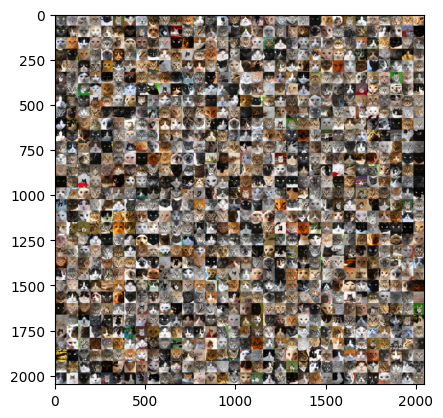

In [29]:
style_gan_fakes_path = "/home/mytkom/Documents/DL/stylegan2-ada-pytorch/outputs/00003-cats-auto1-batch4/fakes000800.png"
# Load and display the image
image = Image.open(style_gan_fakes_path)
plt.imshow(image)
# split into images of size 64x64
images = []
for i in range(0, image.size[0], 64):
    for j in range(0, image.size[1], 64):
        box = (i, j, i + 64, j + 64)
        img = image.crop(box)
        images.append(img)

from utils.clipmmd import CLIPMMD
config = Config.from_defaults()
config.training.metric_calculation_img_count = len(images)
cmmd = CLIPMMD("cuda", "../data-filtered/cats", config)
cmmd = cmmd.compute_mmd(images)
print(f"CLIPMMD score: {cmmd:.3g}")

In [1]:
import json
import numpy as np

# Constants
DIRS = [f"../logs/unet2d_sweep/run_{i}" for i in range(5, 20 + 1)]
CONFIG_FILES = [f"{dir}/config.json" for dir in DIRS]
FID_FILES = [f"{dir}/fid.csv" for dir in DIRS]
CMMD_FILES = [f"{dir}/cmmd.csv" for dir in DIRS]

# Load configurations
configs = []
for config_file in CONFIG_FILES:
    with open(config_file, 'r') as f:
        configs.append(json.load(f))

# Load FID and CMMD data
cmmd_datas = []
for fid_file, cmmd_file in zip(FID_FILES, CMMD_FILES):
    cmmd_datas.append(np.loadtxt(cmmd_file, delimiter=',', skiprows=1))

# Group configs by learning rate and weight decay
lr_wd_groups = {}
for i, config in enumerate(configs):
    lr = config['training']['lr']
    weight_decay = config['training']['weight_decay']
    key = (lr, weight_decay)
    if key not in lr_wd_groups:
        lr_wd_groups[key] = []
    lr_wd_groups[key].append((i, cmmd_datas[i]))

# Print learning rate and weight decay groups and their runs
print("Learning rate and weight decay groups and their runs:")
for (lr, weight_decay), runs in lr_wd_groups.items():
    print(f"LR: {lr}, Weight Decay: {weight_decay}: {len(runs)} runs")
    print(f"Runs: {runs}")
    best_cmmd_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last CMMD score
    print(f"Best CMMD run for LR {lr}, Weight Decay {weight_decay} is run {best_cmmd_run[0]} with CMMD {best_cmmd_run[1][-1, 1]}")
    print(best_cmmd_run[1][-1, 0])

    dir = DIRS[best_cmmd_run[0]]

# Create LaTeX table with learning rate, weight decay, and best CMMD scores
print("\\begin{tabular}{|c|c|c|}")
print("\\hline")
print("Learning Rate & Weight Decay & Best CMMD Score \\\\")
print("\\hline")
for (lr, weight_decay), runs in lr_wd_groups.items():
    best_cmmd_run = min(runs, key=lambda x: x[1][-1, 1])  # Lowest last CMMD score
    print(f"{lr} & {weight_decay} & {best_cmmd_run[1][-1, 1]:.3g} \\\\")
    print("\\hline")
print("\\end{tabular}")

Learning rate and weight decay groups and their runs:
LR: 0.0001, Weight Decay: 0: 2 runs
Runs: [(0, array([[9.33000000e+02, 1.24020525e-03],
       [1.86600000e+03, 1.24476943e-03],
       [2.79900000e+03, 1.10798096e-03],
       [3.73200000e+03, 1.03744981e-03],
       [4.66500000e+03, 1.01557025e-03]])), (2, array([[9.33000000e+02, 1.16118114e-03],
       [1.86600000e+03, 1.24474941e-03],
       [2.79900000e+03, 1.13848434e-03],
       [3.73200000e+03, 1.07701286e-03],
       [4.66500000e+03, 1.06470264e-03]]))]
Best CMMD run for LR 0.0001, Weight Decay 0 is run 0 with CMMD 0.0010155702475458384
4665.0
LR: 0.0001, Weight Decay: 0.0001: 2 runs
Runs: [(1, array([[9.33000000e+02, 1.20744808e-03],
       [1.86600000e+03, 1.24183774e-03],
       [2.79900000e+03, 1.13806047e-03],
       [3.73200000e+03, 1.01811113e-03],
       [4.66500000e+03, 1.01351761e-03]])), (3, array([[9.33000000e+02, 1.16163655e-03],
       [1.86600000e+03, 1.24446396e-03],
       [2.79900000e+03, 1.13706652e-03],
